# Logistic Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

#### 1. Data Exploration:

In [2]:
data = pd.read_csv("diabetes.csv")
print("Data loaded. Shape:", data.shape)

Data loaded. Shape: (768, 9)


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [6]:
data.duplicated().sum()

np.int64(0)

#### Histograms

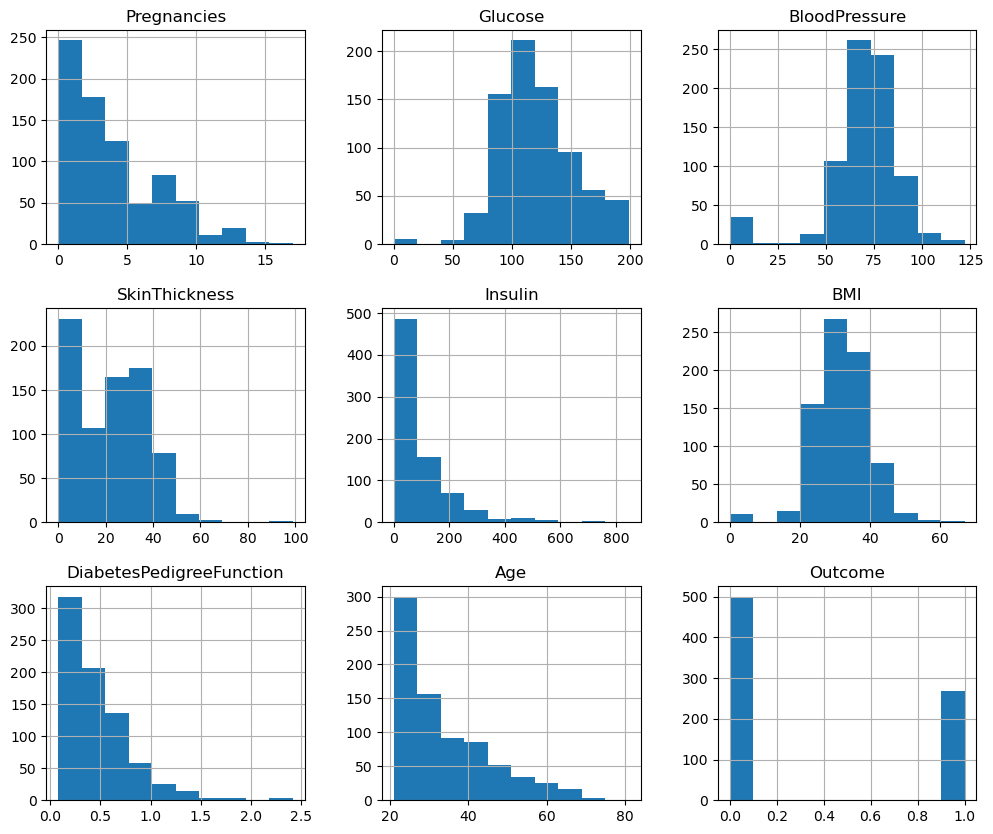

In [7]:
data.hist(figsize=(12,10))
plt.show()

#### Boxplot

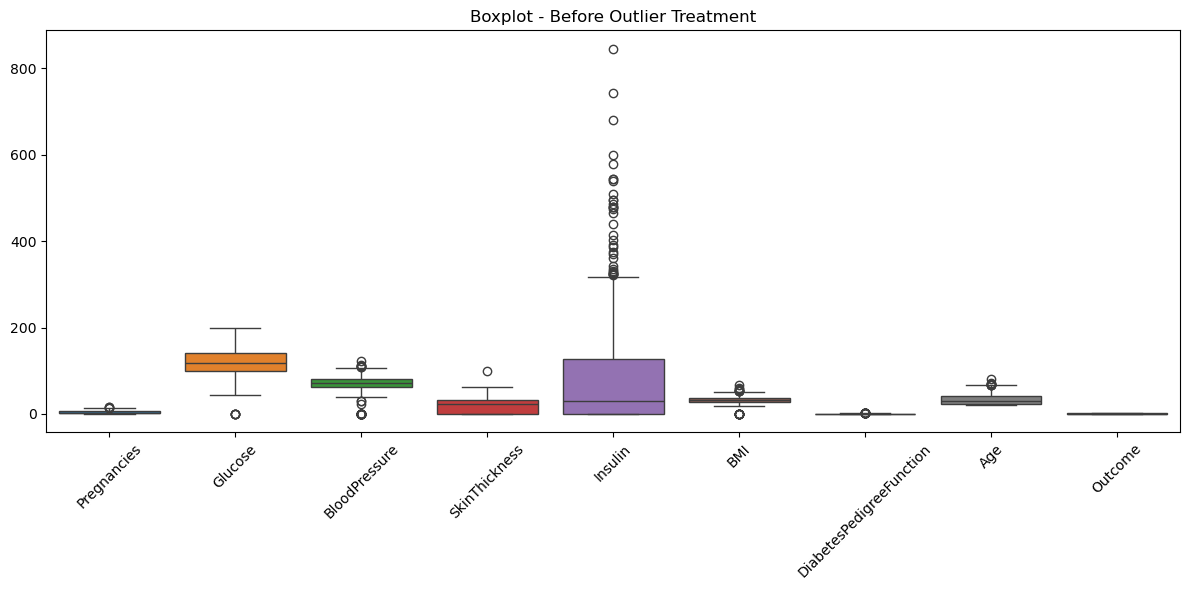

In [8]:
## Boxplot BEFORE Outlier Treatment
plt.figure(figsize=(12, 6))
sns.boxplot(data=data)
plt.title('Boxplot - Before Outlier Treatment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
def outlier_capping(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    data[column] = data[column].apply(lambda x: lower if x < lower else upper if x > upper else x)

for col in data.select_dtypes(include=["int", "float"]).columns:
    if col != "Outcome":
        outlier_capping(data, col)

data.fillna(data.mean(), inplace=True)
data.drop_duplicates(inplace=True)

X = data.drop("Outcome", axis=1)
y = data["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7467532467532467


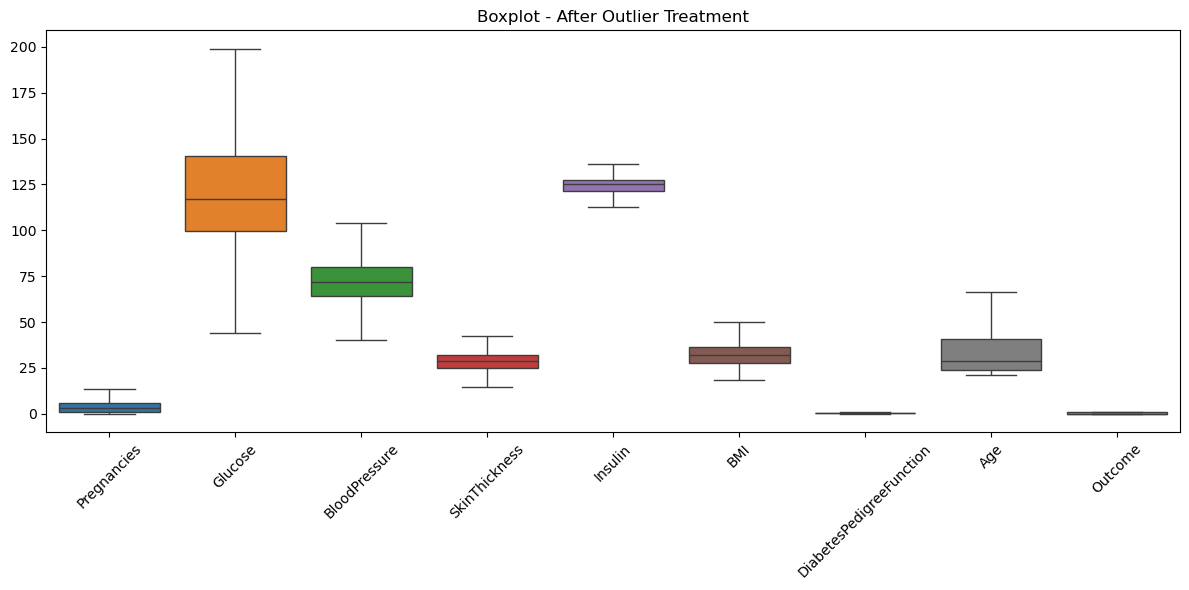

In [25]:
# Boxplot - after Oi=utlier treatment
plt.figure(figsize=(12, 6))
sns.boxplot(data=data)
plt.title('Boxplot - After Outlier Treatment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Correlation Heatmap

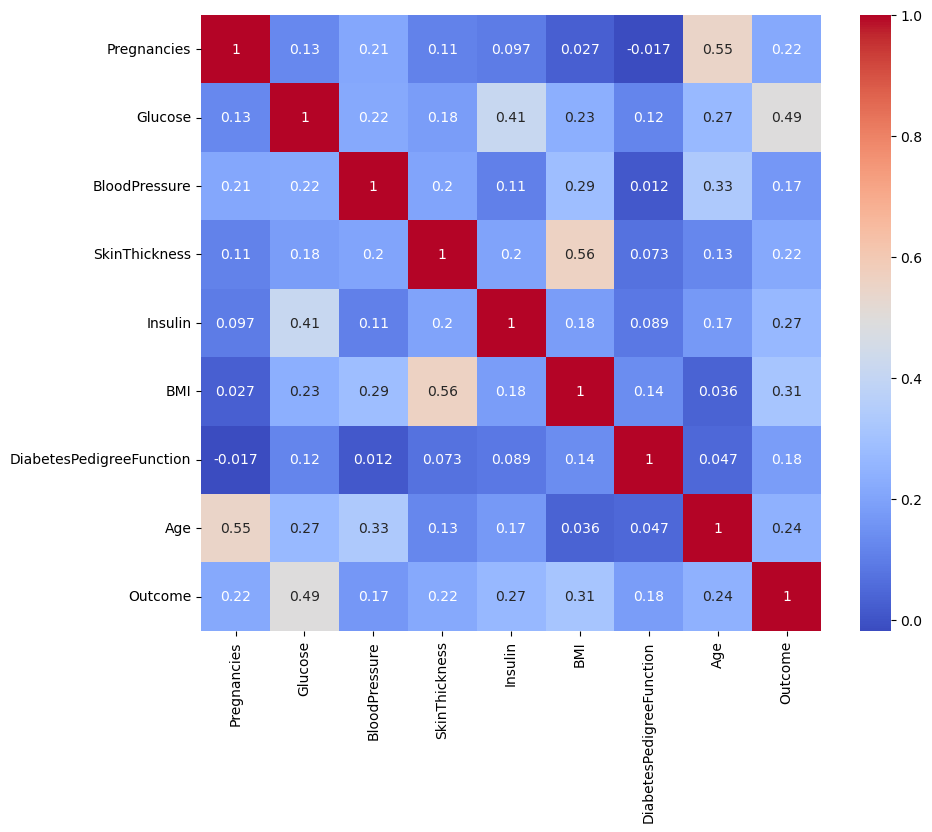

In [26]:
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.show()

#### Interpretation

##### Multicollinearity Check: The correlation matrix shows that all predictor variables have correlation coefficients below 0.7, indicating no significant multicollinearity. Hence, all features were retained for model training.

### Handling missing values

In [10]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols:
    data[col] = data[col].replace(0, np.nan)
    data[col] = data[col].fillna(data[col].median())

### Features and Target

In [11]:
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape 

((614, 8), (154, 8), (614,), (154,))

In [13]:
#build the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [14]:
#prediction
y_pred = model.predict(X_test)

In [15]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision :",precision_score(y_test, y_pred))
print("Recall :",recall_score(y_test, y_pred))
print("F1 Score :",f1_score(y_test, y_pred))

Accuracy : 0.7532467532467533
Precision : 0.6666666666666666
Recall : 0.6181818181818182
F1 Score : 0.6415094339622641


In [29]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.81      0.80        99
           1       0.65      0.64      0.64        55

    accuracy                           0.75       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



In [30]:
#ROC-AUC
def plot_roc(y, y_prob):
    fpr, tpr, thresh = roc_curve(y, y_prob)
    auc = roc_auc_score(y, y_prob)

    print("ROC - AUC Score:", auc)

    plt.figure(figsize=(5,5))
    plt.title("ROC Curve", fontsize=15)
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR)")

    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    plt.plot([0, 1],[0, 1], 'r--', label="Random Classifier")

    plt.legend(loc="lower right")
    plt.show()


ROC - AUC Score: 0.826078971533517
ROC - AUC Score: 0.826078971533517


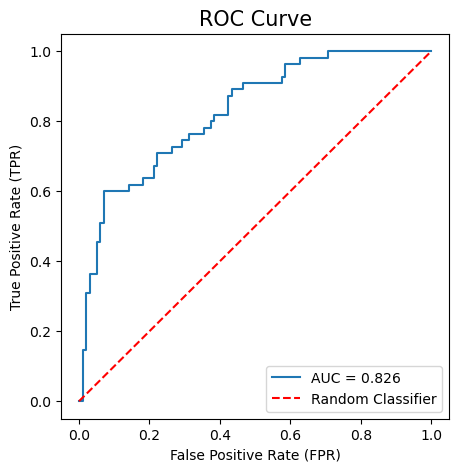

In [31]:
y_prob = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC - AUC Score:", roc_auc)
plot_roc(y_test, y_prob)

#### Interpretation

#### Feature Significance: Features with larger absolute coefficient values contribute more to predicting diabetes.



In [32]:
#Coefficient interpretation
coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient":model.coef_[0]
})
coef.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
6,DiabetesPedigreeFunction,0.777942
5,BMI,0.100076
0,Pregnancies,0.063387
7,Age,0.037705
1,Glucose,0.033506
4,Insulin,0.016159
3,SkinThickness,0.008291
2,BloodPressure,-0.013278


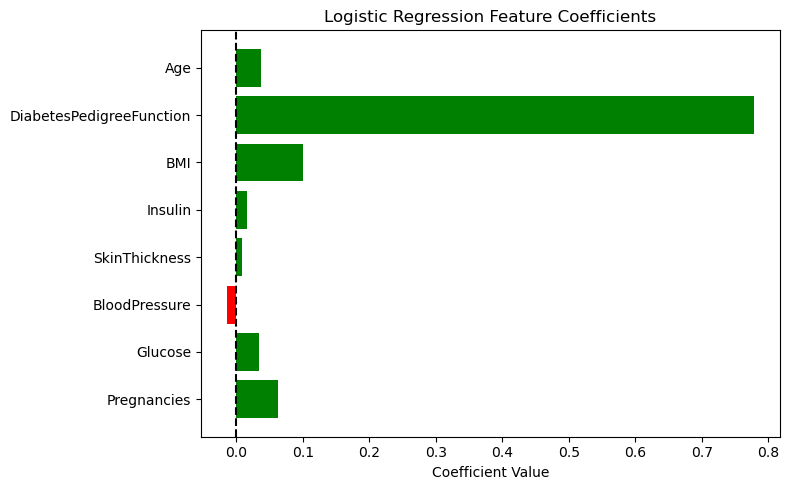

In [35]:
## Coefficient Bar Chart
plt.figure(figsize=(8, 5))
colors = ['green' if c > 0 else 'red' for c in coef['Coefficient']]
plt.barh(coef['Feature'], coef['Coefficient'], color=colors)
plt.xlabel('Coefficient Value')
plt.title('Logistic Regression Feature Coefficients')
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

#### Deployment

In [19]:
from pickle import dump

In [20]:
dump(model, open('model.pkl', 'wb'))

In [21]:
!pip install streamlit

### STREAMLIT DEPLOYMENT
##### The Logistic Regression model has been deployed using Streamlit to provide an interactive web application for diabetes prediction.

##### **Features of the application:**
##### - Loads the trained Logistic Regression model (`model.pkl`).
##### - Accepts user inputs for:
##### - Pregnancies
##### - Glucose
##### - Blood Pressure
##### - Skin Thickness
##### - Insulin
##### - BMI
##### - Diabetes Pedigree Function
##### - Age
##### - Predicts whether the patient is **Diabetic** or **Not Diabetic**.
##### - Displays the prediction through an interactive user interface.

##### **GitHub Repository:**
##### https://github.com/Pranjali768/Data_Science_Assignments/tree/main/08_Logistic_Regression
    
##### **Streamlit Deployment:
##### https://diabetesprediction-gxkdhvzknqbpbjal67hln8.streamlit.app/

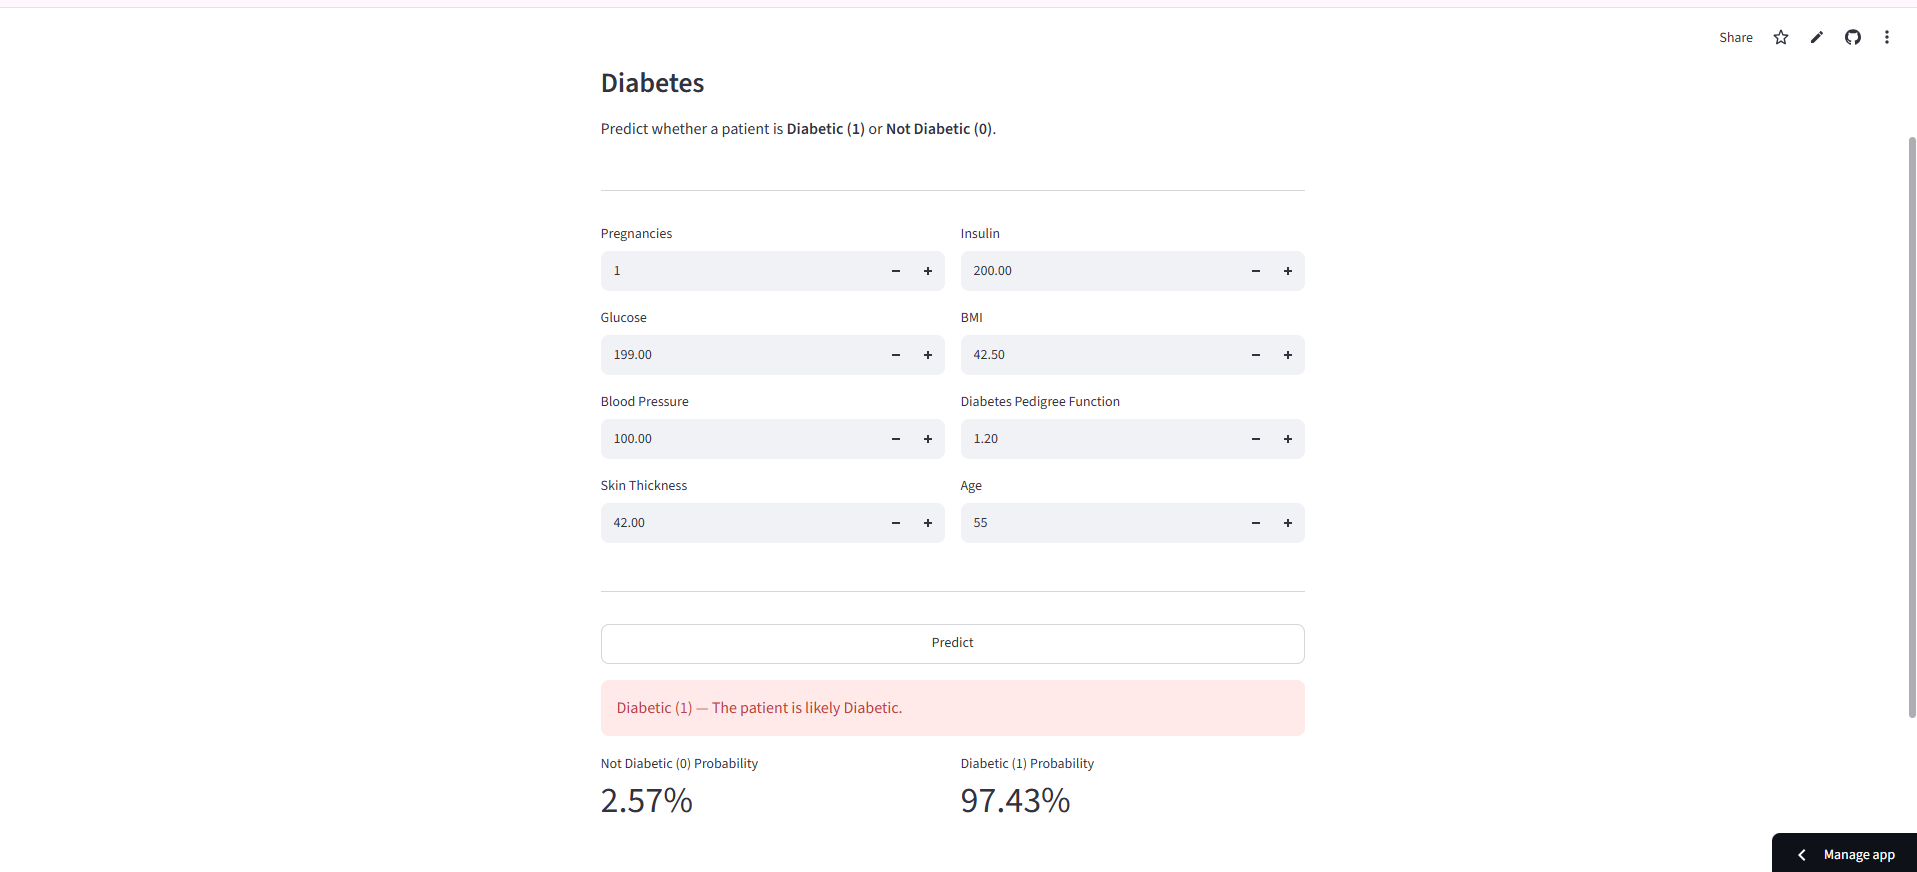

### Interview Questions

#### 1. What is the difference between Precision and Recall?

##### Precision measures how many positive predictions made by the model are actually correct, while recall measures how many actual positive cases are correctly identified by the model.

##### 1. Precision is important when the cost of false positives is high.
##### 2. Recall is important when the cost of false negatives is high.


#### FORMULA:
##### PRECISION = TP/(TP + FP)
##### RECALL = TP/(TP + FN)

#### 2. What is Cross-Validation and Why is it Important in Binary Classification?



##### Cross-validation is a technique used to evaluate a model by testing it on different subsets of data. It helps improve reliability, reduces overfitting, and provides a better estimate of model performance on unseen data

##### Importance in Binary Classification:

##### 1. Provides a more reliable estimate of model performance.
##### 2. Helps detect overfitting and underfitting.
##### 3. Ensures the model generalizes well to unseen data.
##### 4. Makes efficient use of the available dataset.
##### 5. Improves the robustness and stability of the model evaluation.
